Sql


In [2]:

!pip install matplotlib seaborn pandas numpy scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130

In [3]:
orders      = pd.read_csv("corrected_orders.csv")
deliveries  = pd.read_csv("corrected_deliveries.csv")
customers   = pd.read_csv("corrected_customers.csv")
drivers     = pd.read_csv("corrected_drivers.csv")
vehicles    = pd.read_csv("corrected_vehicles.csv")
complaints  = pd.read_csv("corrected_complaints.csv")
incidents   = pd.read_csv("corrected_incidents.csv")
app_events  = pd.read_csv("corrected_app_events.csv")

In [4]:
datasets = {
    "orders": orders,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles,
    "app_events": app_events
}

for name, df in datasets.items():

    if name == "orders":
        cols = ["pickup_zone", "dropoff_zone"]
    elif name == "customers":
        cols = ["home_zone"]
    elif name == "drivers":
        cols = ["base_zone"]
    elif name == "vehicles":
        cols = ["assigned_zone"]
    elif name == "hubs":
        cols = ["zone"]
    elif name == "app_events":
        cols = ["zone_context"]
    else:
        cols = []

    for col in cols:
        df[col] = df[col].astype(str).str.strip().str.title()

deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"], errors="coerce")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce")

orders["order_created_at"] = pd.to_datetime(orders["order_created_at"], errors="coerce")
complaints["created_at"] = pd.to_datetime(complaints["created_at"], errors="coerce")
app_events["event_timestamp"] = pd.to_datetime(app_events["event_timestamp"], errors="coerce")

deliveries["actual_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

deliveries["duration_valid"] = deliveries["actual_hours"].between(0, 200)

orders["order_month"] = orders["order_created_at"].dt.to_period("M")

print("All datasets cleaned successfully!")
print("Orders:", len(orders), "| Deliveries:", len(deliveries), "| Customers:", len(customers))
print("Invalid delivery durations:", (~deliveries["duration_valid"]).sum())

All datasets cleaned successfully!
Orders: 1250 | Deliveries: 950 | Customers: 650
Invalid delivery durations: 83


Analysis 1 - Fuel/Charge Cost vs Delivery Outcome


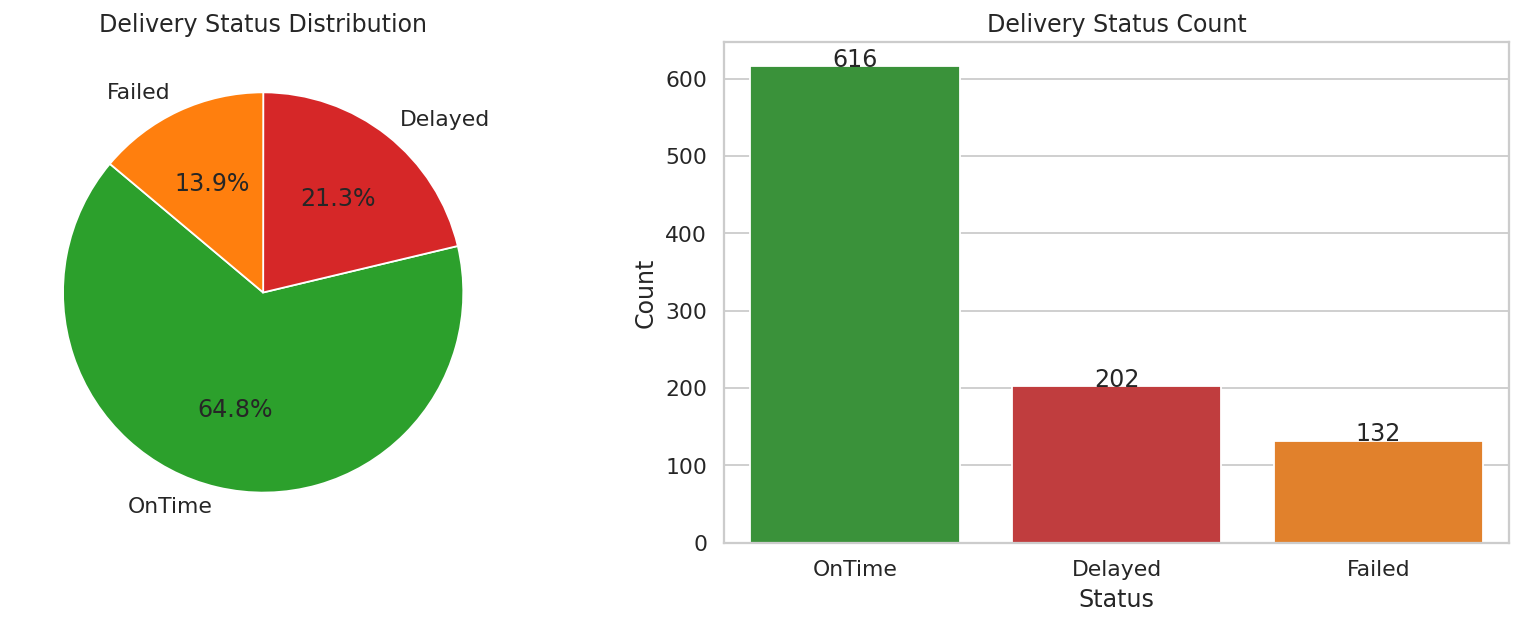

Saved as delivery_status.png


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


status_counts = deliveries["delivery_status"].value_counts()

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)

colors = ["#2CA02C", "#D62728", "#FF7F0E", "#AEC7E8"]

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=colors[:len(status_counts)],
    startangle=140
)

plt.title("Delivery Status Distribution")

plt.subplot(1, 2, 2)

sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    palette=colors[:len(status_counts)]
)

plt.title("Delivery Status Count")
plt.xlabel("Status")
plt.ylabel("Count")


for i, value in enumerate(status_counts.values):
    plt.text(i, value, str(value), ha="center")

plt.tight_layout()
plt.savefig("delivery_status.png")
plt.show()

print("Saved as delivery_status.png")

Analysis 2 - Vehicle Battery Health vs Incident Count

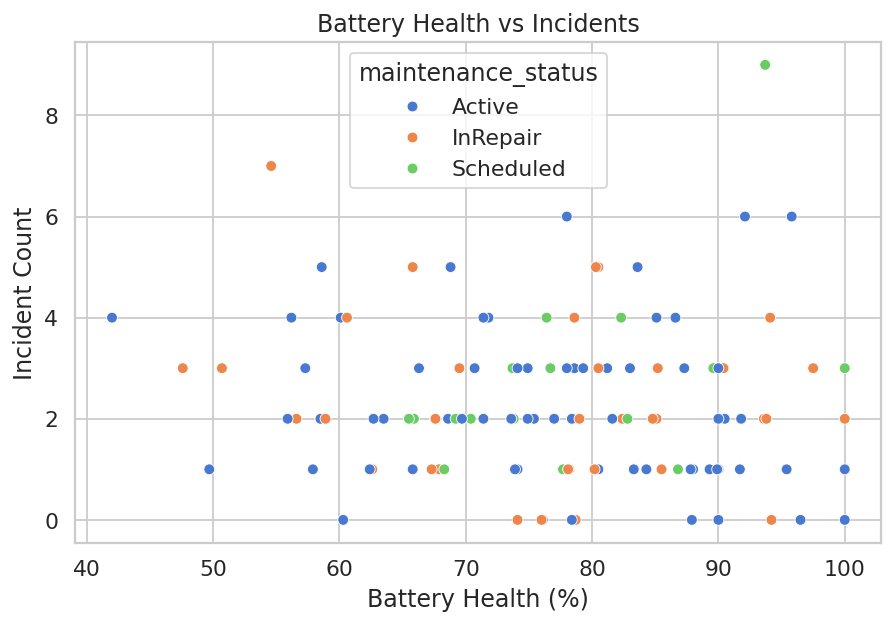

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = incidents.merge(deliveries[['delivery_id', 'vehicle_id']], on='delivery_id')

inc_count = data.groupby('vehicle_id')['incident_id'].count().reset_index()
inc_count.columns = ['vehicle_id', 'incident_count']

veh = vehicles.merge(inc_count, on='vehicle_id', how='left')

veh['incident_count'] = veh['incident_count'].fillna(0)


plt.figure(figsize=(8,5))

sns.scatterplot(
    data=veh,
    x='battery_health_pct',
    y='incident_count',
    hue='maintenance_status'
)

plt.title("Battery Health vs Incidents")
plt.xlabel("Battery Health (%)")
plt.ylabel("Incident Count")

plt.show()

Analysis 3 - Fuel/Charge Cost vs Delivery Outcome


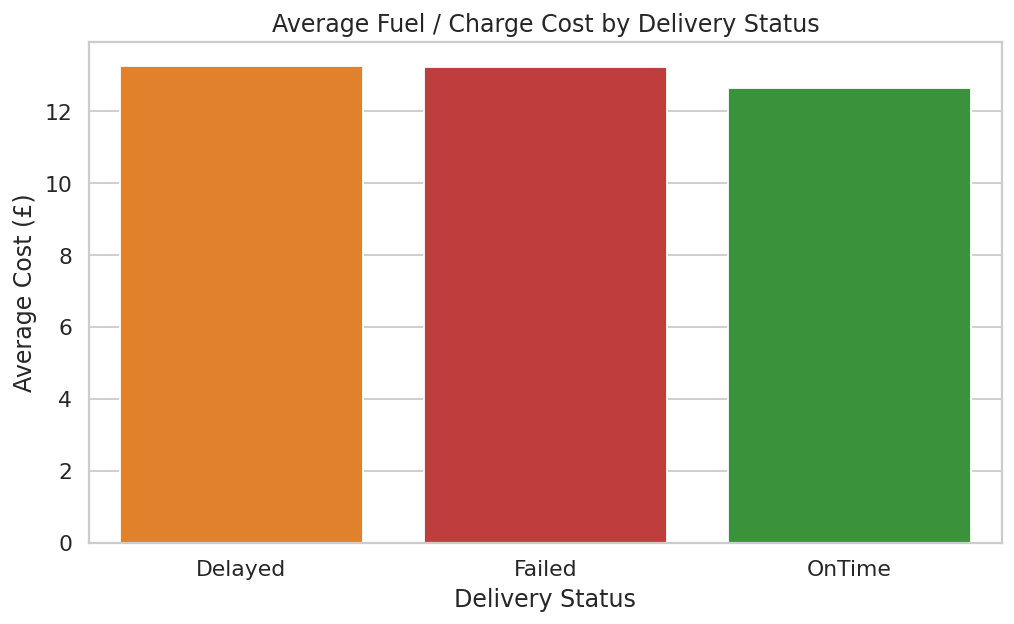

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate average cost per delivery status
avg_cost = ord_del_clean.groupby("delivery_status")["fuel_or_charge_cost"].mean().reset_index()

# 2. Plot bar chart
plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_cost,
    x="delivery_status",
    y="fuel_or_charge_cost",
    palette={"Failed": "#D62728", "OnTime": "#2CA02C",
             "Delayed": "#FF7F0E"} # Corrected palette
)

plt.title("Average Fuel / Charge Cost by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Cost (£)")
plt.tight_layout()
plt.show()

Analysis 4 — Driver Experience vs Failure Rate

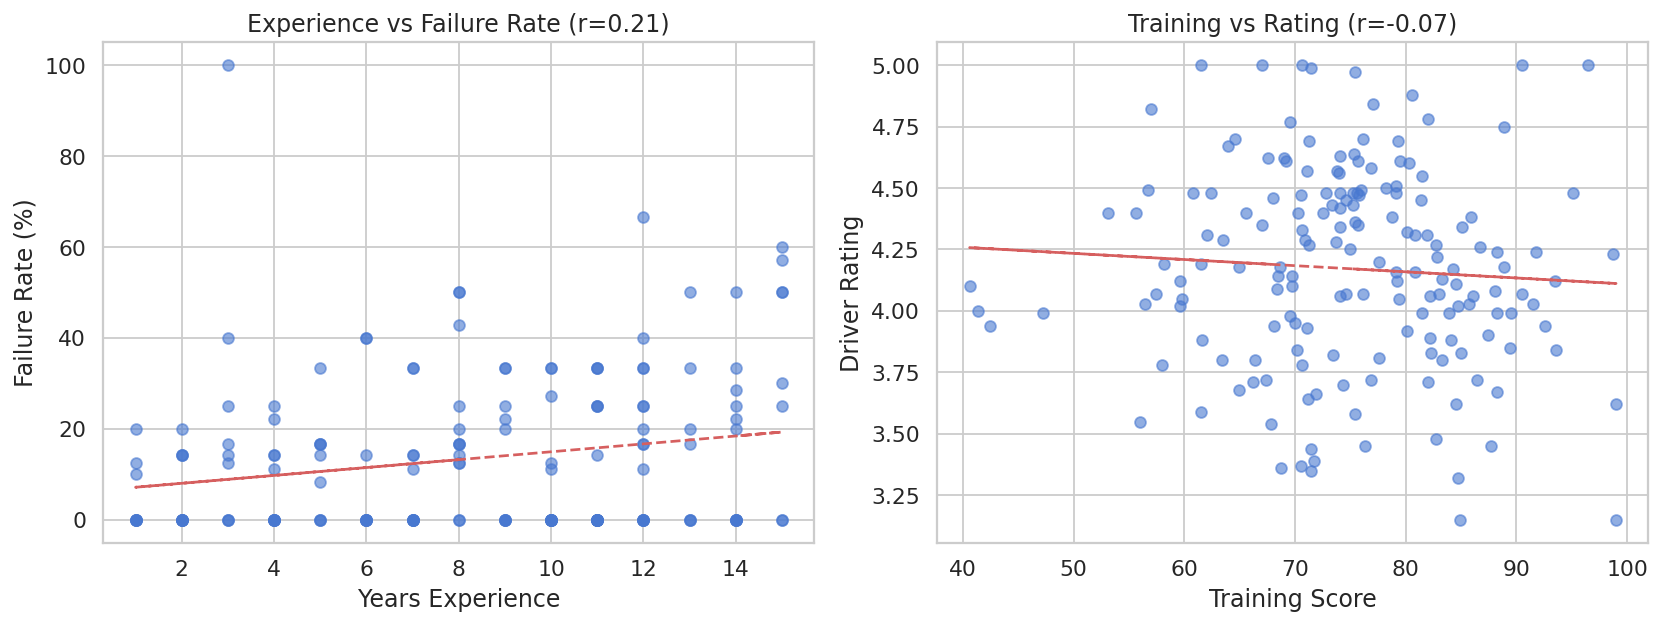

In [19]:

driver_perf = deliveries.groupby("driver_id").agg(
    total_deliveries=("delivery_id", "count"),
    failed=("delivery_status", lambda x: (x == "Failed").sum()),
    avg_overrides=("manual_route_override_count", "mean")
).reset_index()

driver_perf["fail_rate"] = 100 * driver_perf["failed"] / driver_perf["total_deliveries"]

driver_perf = driver_perf.merge(drivers, on="driver_id")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))



axes[0].scatter(driver_perf["years_experience"],
                driver_perf["fail_rate"],
                alpha=0.6)

m, b, r, p, _ = stats.linregress(
    driver_perf["years_experience"],
    driver_perf["fail_rate"]
)

axes[0].plot(driver_perf["years_experience"],
             m * driver_perf["years_experience"] + b,
             "r--")

axes[0].set_title(f"Experience vs Failure Rate (r={r:.2f})")
axes[0].set_xlabel("Years Experience")
axes[0].set_ylabel("Failure Rate (%)")


axes[1].scatter(driver_perf["training_score"],
                driver_perf["driver_rating"],
                alpha=0.6)

m2, b2, r2, p2, _ = stats.linregress(
    driver_perf["training_score"],
    driver_perf["driver_rating"]
)

axes[1].plot(driver_perf["training_score"],
             m2 * driver_perf["training_score"] + b2,
             "r--")

axes[1].set_title(f"Training vs Rating (r={r2:.2f})")
axes[1].set_xlabel("Training Score")
axes[1].set_ylabel("Driver Rating")

plt.tight_layout()
plt.savefig("driver_analysis.png")
plt.show()

Analysis 5 — App Event API Latency Analysis

                    event_type   mean  median    std  count
3  delivery_instruction_update  496.3   446.0  277.3     75
2                  chat_opened  478.3   416.5  311.4     88
1               chat_escalated  478.1   411.0  315.3     38
5                payment_retry  472.7   440.0  287.2     69
7                  track_order  460.7   427.0  278.4    138
6                 search_route  456.5   457.0  228.6     99
4                  eta_refresh  452.2   440.0  248.0    105
0               cancel_attempt  417.1   414.0  228.8     28


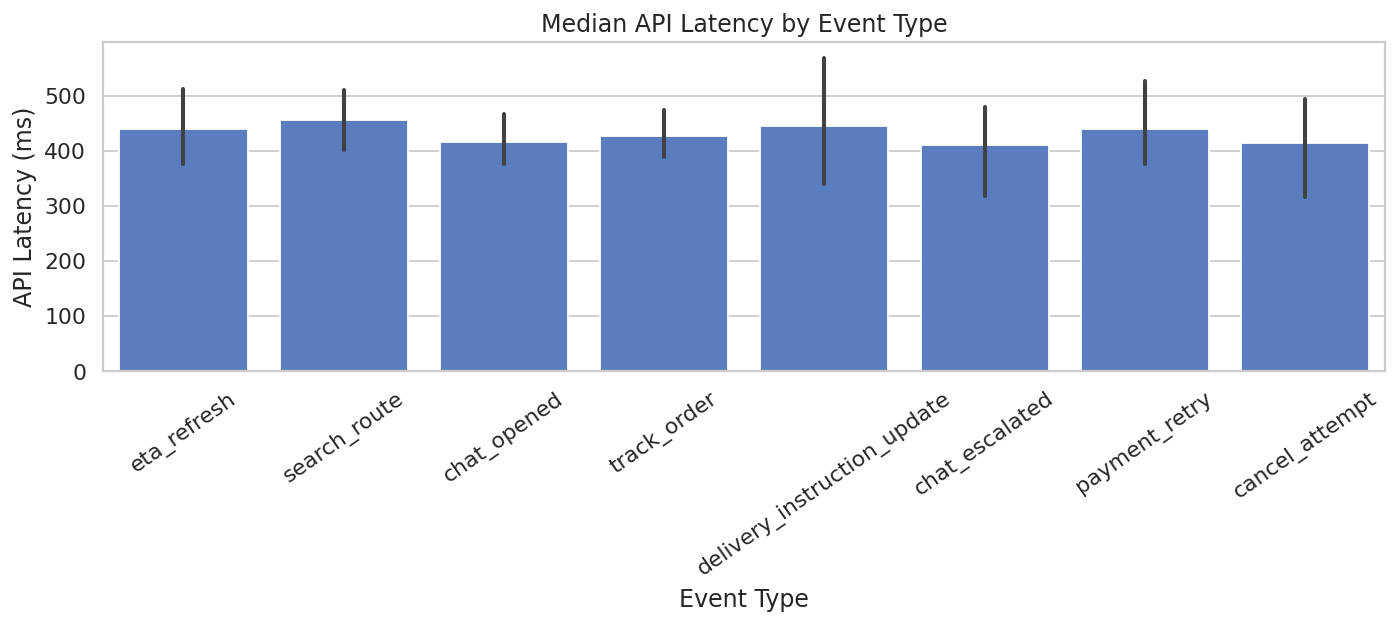

In [20]:
latency_event = app_events.groupby("event_type")["api_latency_ms"].agg(["mean", "median", "std", "count"]).round(1).reset_index().sort_values("mean", ascending=False)

print(latency_event)

plt.figure(figsize=(11, 5))
sns.barplot(data=app_events, x="event_type", y="api_latency_ms", estimator=np.median)
plt.title("Median API Latency by Event Type")
plt.xlabel("Event Type")
plt.ylabel("API Latency (ms)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

R Analysis

In [3]:


suppressPackageStartupMessages({
library(ggplot2)
library(dplyr)
library(lubridate)
library(tidyr)
library(scales)
library(readr)
install.packages("corrplot", repos = "http://cran.us.r-project.org", quiet = TRUE)
library(corrplot)
})

orders      <- read_csv("corrected_orders.csv")
deliveries  <- read_csv("corrected_deliveries.csv")
customers   <- read_csv("corrected_customers.csv")
drivers     <- read_csv("corrected_drivers.csv")
vehicles    <- read_csv("corrected_vehicles.csv")
complaints  <- read_csv("corrected_complaints.csv")
incidents   <- read_csv("corrected_incidents.csv")
app_events  <- read_csv("corrected_app_events.csv")

standardise_zone <- function(x) tools::toTitleCase(tolower(trimws(x)))
orders$pickup_zone    <- standardise_zone(orders$pickup_zone)
customers$home_zone   <- standardise_zone(customers$home_zone)
drivers$base_zone     <- standardise_zone(drivers$base_zone)
vehicles$assigned_zone <- standardise_zone(vehicles$assigned_zone)


deliveries$dispatch_time         <- ymd_hms(deliveries$dispatch_time)
deliveries$delivery_completed_at <- ymd_hms(deliveries$delivery_completed_at)
orders$order_created_at          <- ymd_hms(orders$order_created_at)


deliveries$actual_hours <- as.numeric(
  difftime(deliveries$delivery_completed_at, deliveries$dispatch_time, units = "hours")
)

Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): delivery_id, order_id, driver_id, vehicle_id, hub_id, delivery_status
dbl  (5): route_distance_km, manual_route_override_count, proof_of_completio...
dttm (2): dispatch_time, delivery_completed_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 650 Columns: 9
── Column specification ──────────────────────────

Analysis 1 — Delivery Status Distribution by Hub

Rows: 8 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): hub_id, hub_name, zone, hub_type
dbl (1): capacity_score

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


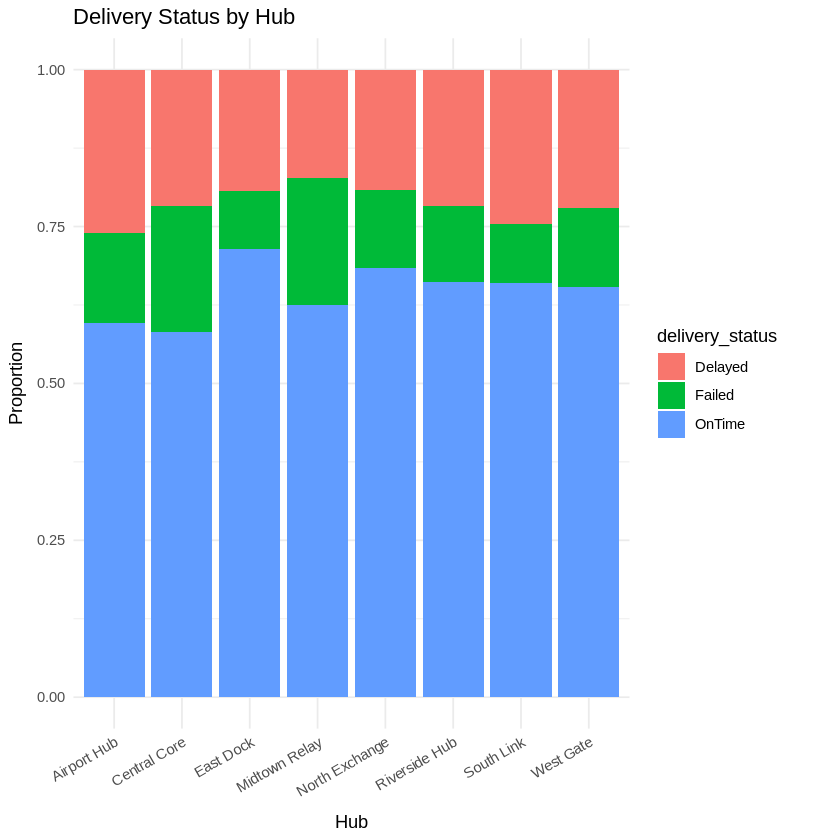

In [7]:
library(dplyr)
library(ggplot2)
library(readr)

hubs <- read_csv("hubs.csv")


del_hub <- deliveries %>%
  left_join(hubs, by = "hub_id") %>%
  filter(!is.na(hub_name))

hub_status <- del_hub %>%
  group_by(hub_name, delivery_status) %>%
  summarise(count = n(), .groups = "drop")

ggplot(hub_status, aes(x = hub_name, y = count, fill = delivery_status)) +
  geom_bar(stat = "identity", position = "fill") +
  labs(title = "Delivery Status by Hub",
       x = "Hub",
       y = "Proportion") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

Analysis 2: — Delivery Failure Rate by Zone (Map-Style Bar)

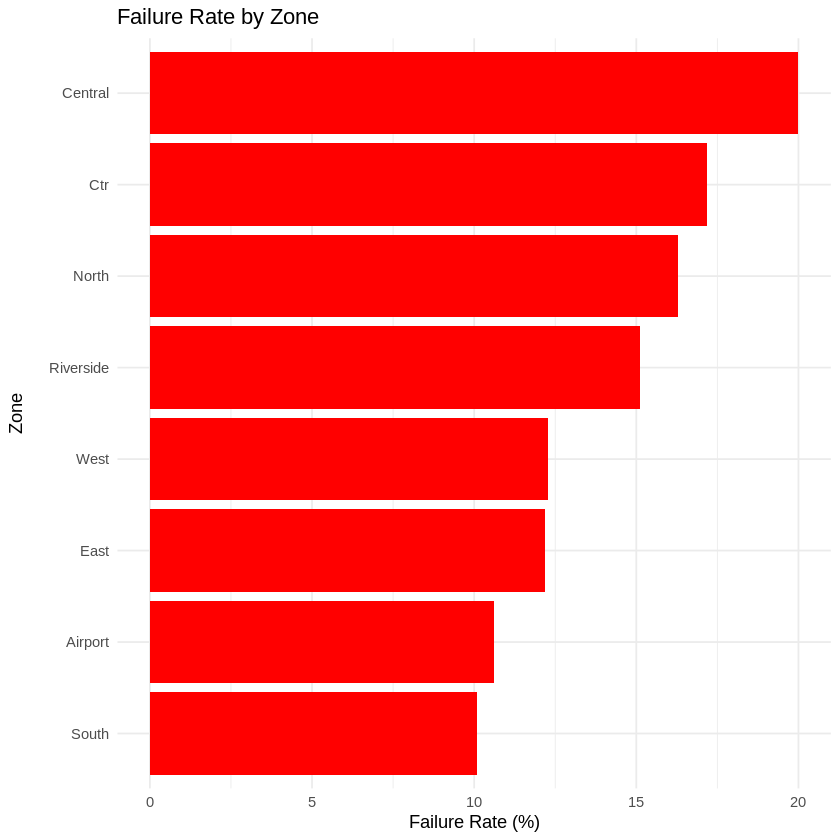

In [8]:
library(dplyr)
library(ggplot2)

ord_del <- orders %>%
  left_join(deliveries, by = "order_id") %>%
  filter(!is.na(delivery_status))

zone_fail <- ord_del %>%
  group_by(pickup_zone) %>%
  summarise(
    total = n(),
    failed = sum(delivery_status == "Failed"),
    fail_rate = 100 * failed / total,
    .groups = "drop"
  )


ggplot(zone_fail, aes(x = reorder(pickup_zone, fail_rate), y = fail_rate)) +
  geom_col(fill = "red") +
  coord_flip() +
  labs(title = "Failure Rate by Zone",
       x = "Zone",
       y = "Failure Rate (%)") +
  theme_minimal()

Analysis 3 — Complaint Severity & Resolution Days Distribution

Call:
   aov(formula = resolution_days ~ severity, data = comp_clean)

Terms:
                severity Residuals
Sum of Squares  2737.824  5935.523
Deg. of Freedom        2       317

Residual standard error: 4.327129
Estimated effects may be unbalanced

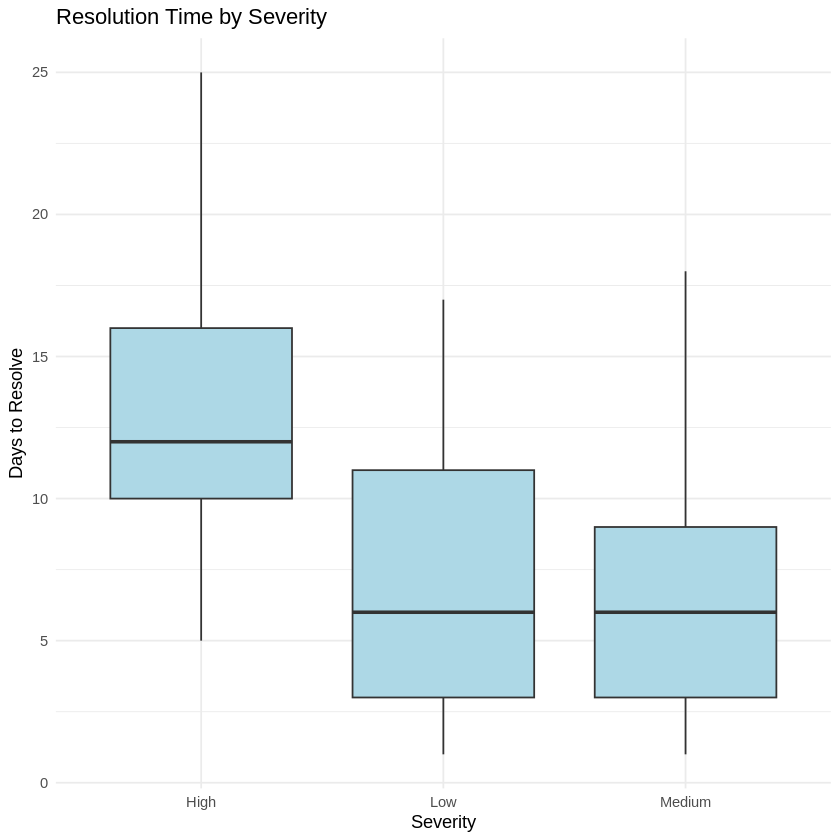

In [9]:
library(dplyr)
library(ggplot2)

comp_clean <- complaints %>%
  filter(!is.na(resolution_days), !is.na(severity))

ggplot(comp_clean, aes(x = severity, y = resolution_days)) +
  geom_boxplot(fill = "lightblue") +
  labs(title = "Resolution Time by Severity",
       x = "Severity",
       y = "Days to Resolve") +
  theme_minimal()

aov(resolution_days ~ severity, data = comp_clean)

Analysis 4 — Monthly Order Volume Trend

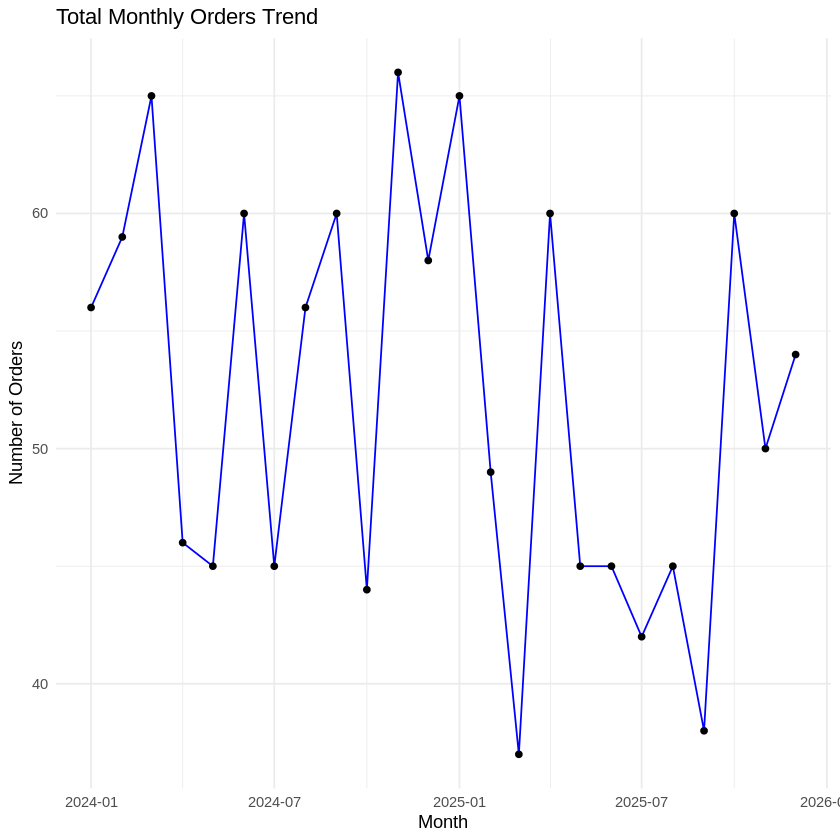

In [10]:
library(dplyr)
library(ggplot2)
library(lubridate)

orders$month <- floor_date(ymd_hms(orders$order_created_at), "month")

monthly_total <- orders %>%
  group_by(month) %>%
  summarise(total_orders = n(), .groups = "drop")

ggplot(monthly_total, aes(x = month, y = total_orders)) +
  geom_line(color = "blue") +
  geom_point() +
  labs(title = "Total Monthly Orders Trend",
       x = "Month",
       y = "Number of Orders") +
  theme_minimal()

RCA -Analyzing Performance vs Training

In [5]:
install.packages("sqldf", repos = "http://cran.us.r-project.org")
library(sqldf)


deliveries <- read.csv("corrected_deliveries.csv") # Corrected filename
drivers <- read.csv("corrected_drivers.csv")
hubs <- read.csv("hubs.csv")


performance_gap_analysis <- sqldf("
  SELECT
    h.hub_name,
    CASE
      WHEN dr.training_score < 50 THEN 'Low Training'
      WHEN dr.training_score BETWEEN 50 AND 80 THEN 'Standard'
      ELSE 'High Training'
    END AS training_tier,
    AVG(d.customer_rating_post_delivery) AS avg_customer_rating,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(d.delivery_id) AS failure_rate_pct,
    COUNT(d.delivery_id) AS total_deliveries
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY 1, 2
  ORDER BY failure_rate_pct DESC
")

print(performance_gap_analysis)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



         hub_name training_tier avg_customer_rating failure_rate_pct
1       West Gate  Low Training            2.590000       100.000000
2     Airport Hub  Low Training            4.423333        33.333333
3       East Dock  Low Training            3.603333        33.333333
4     Airport Hub High Training            4.026316        26.315789
5    Central Core      Standard            3.815135        22.972973
6   Midtown Relay High Training            3.829375        22.916667
7   Midtown Relay      Standard            3.922004        19.480519
8   Riverside Hub High Training            3.881157        16.666667
9      South Link  Low Training            3.986111        16.666667
10   Central Core High Training            3.449123        15.789474
11 North Exchange High Training            3.892979        14.893617
12      West Gate High Training            3.833989        14.893617
13 North Exchange      Standard            3.792266        11.494253
14  Riverside Hub      Standard   

App Latency vs. Failed Service

In [9]:
app_events <- read.csv("corrected_app_events.csv")
deliveries <- read.csv("corrected_deliveries.csv")

tech_impact_analysis <- sqldf("
  SELECT
    a.zone_context,
    AVG(a.api_latency_ms) AS avg_lag,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS total_failures
  FROM app_events a
  JOIN deliveries d ON a.order_id = d.order_id
  GROUP BY 1
  ORDER BY avg_lag DESC
")

print(tech_impact_analysis)

   zone_context  avg_lag total_failures
1       AIRPORT 646.8889              6
2       Central 506.3333              1
3         north 493.7273              4
4       CENTRAL 481.2857              4
5       Airport 479.1429              5
6           Ctr 453.3333              3
7          EAST 451.8125              5
8         South 448.0000              6
9          East 421.4000              5
10        SOUTH 420.3421              6
11         WEST 415.7609              5
12        North 412.5000              2
13    RiverSide 410.2632              6
14         West 409.0833              5
15    Riverside 408.6944              2
16        NORTH 395.1053              3
